In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10, 6)

In [9]:
df = pd.read_csv('~/my_proj/data/car data.csv')

print("DatasetSize:", df.shape)
df.head()

DatasetSize: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [16]:
df.info()
print("\n  KEY STATS")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

  KEY STATS
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.10000

In [17]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print("NUMERICAL CHARACTERISTICS:", numeric_cols)


NUMERICAL CHARACTERISTICS: ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']


In [19]:
categoral_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("CATEGORIAL CHARACTERISTICS:", categoral_cols)


CATEGORIAL CHARACTERISTICS: ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


In [20]:
target_col='Selling_Price'
print(f"\nTARGET VARIABLE: {target_col}")
print("DISTRIBUTION OF THE TARGET VARIABLE:", df[target_col].value_counts())


TARGET VARIABLE: Selling_Price
DISTRIBUTION OF THE TARGET VARIABLE: Selling_Price
0.45     8
0.60     8
4.50     7
5.25     7
4.75     6
        ..
10.11    1
6.40     1
8.55     1
9.50     1
11.50    1
Name: count, Length: 156, dtype: int64


In [21]:
df=df.drop_duplicates()
print("AFTER REMOVING DUPLICATES:", df.shape)

AFTER REMOVING DUPLICATES: (299, 9)


In [22]:
df=df.dropna()
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

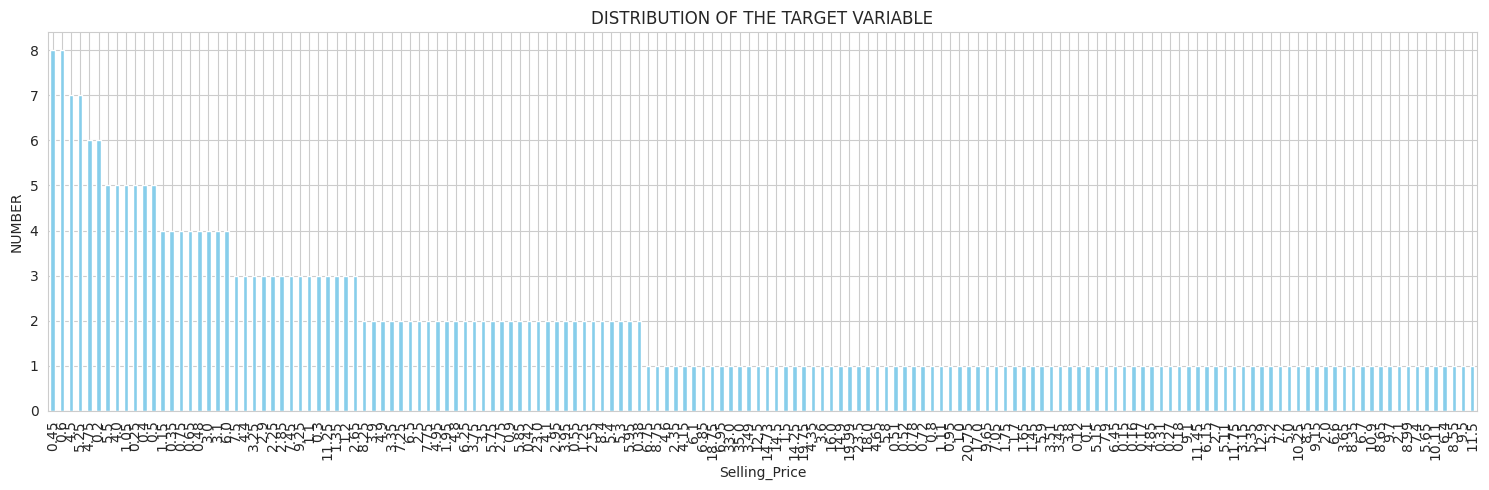

In [26]:
plt.figure(figsize=(15,5))
df[target_col].value_counts().plot(kind='bar', color='skyblue')
plt.title('DISTRIBUTION OF THE TARGET VARIABLE')
plt.xlabel(target_col)
plt.ylabel('NUMBER')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('target_distribution.png' , dpi=150)
plt.show

#По этому графику можно сделать вывод, что большинство автомобилей имеют низкую цену продажи, что типично для распределения цен

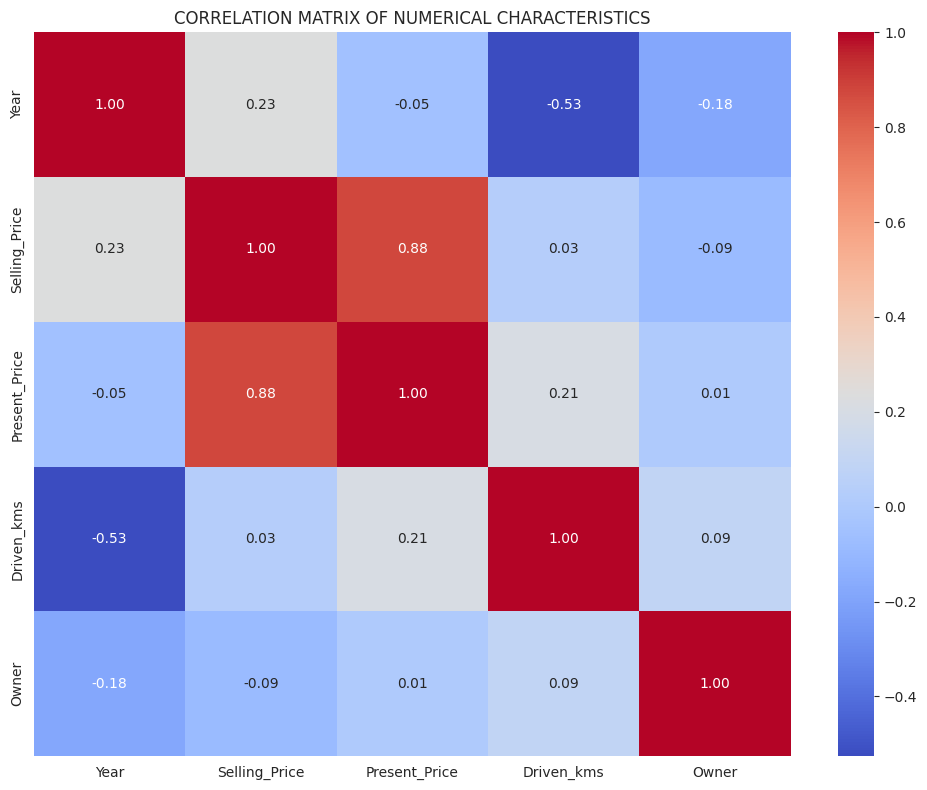

In [27]:
plt.figure(figsize=(10,8))
correlation_matrix=df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('CORRELATION MATRIX OF NUMERICAL CHARACTERISTICS')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

#Самая сильная связь в датасете наблюдается у цены продажи и нынешней цены. Так же можно заметить отрицательную корреляцию у года выпуска автомобиля и его пробегом, потому что чем новее автомобиль, тем меньше будет его пробег. Так же пробег и цена автомобиля, почти не связаны, что является достаточно неожиданным результатом.

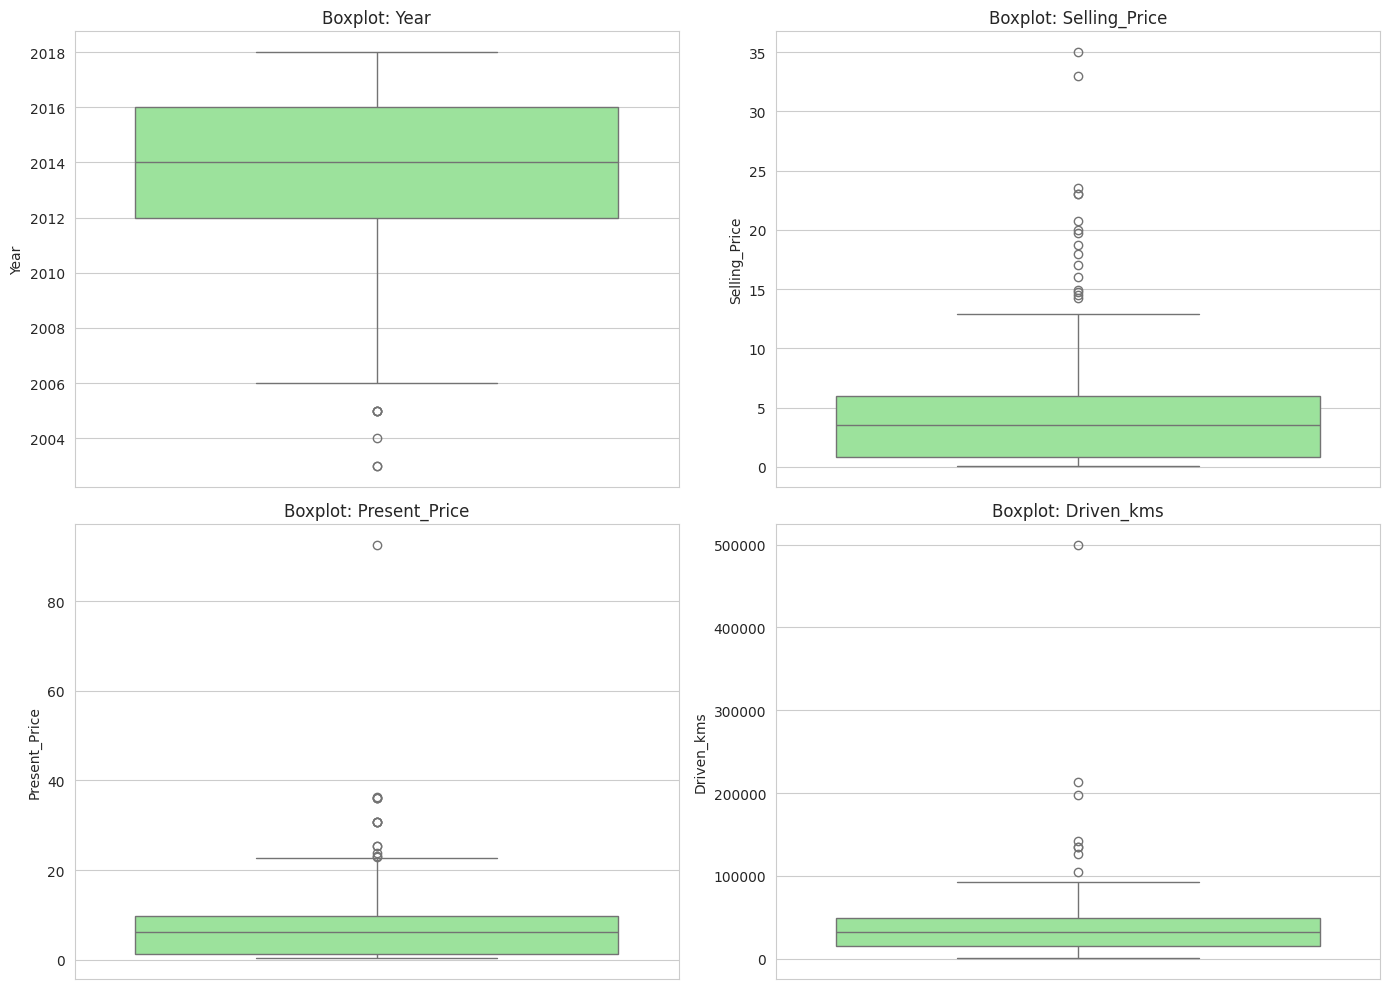

In [28]:
fig, axes = plt.subplots(2,2,figsize=(14,10))
for ax,col in zip(axes.flatten(), numeric_cols[:4]):
    sns.boxplot(data=df, y=col, ax=ax, color='lightgreen')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()

#Большинство автомобилей было выпущено в период с 2012 по 2016 года. Распределение цен подтверждает первый график, большинство автомобилей продаются дешево. Ситуация с текущей ценой повторяет цену продажи. А величина пробега говорит о том, что практически все машины были проданы с низким пробегом.

<Figure size 1000x600 with 0 Axes>

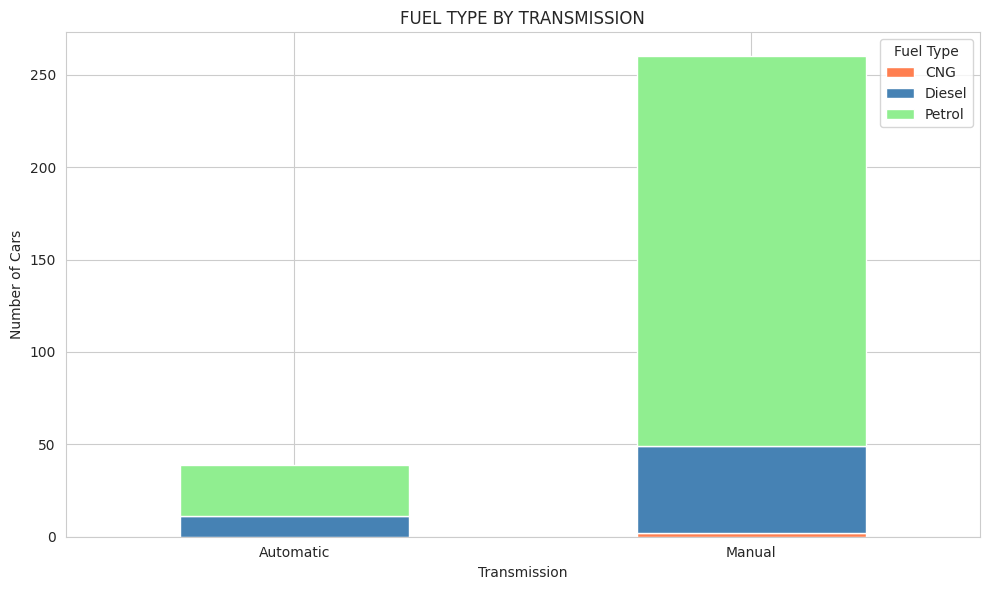

In [35]:
plt.figure(figsize=(10, 6))
fuel_transmission = pd.crosstab(df['Transmission'], df['Fuel_Type'])
fuel_transmission.plot(kind='bar', stacked=True, color=['coral', 'steelblue', 'lightgreen', 'gold'])
plt.title('FUEL TYPE BY TRANSMISSION')
plt.xlabel('Transmission')
plt.ylabel('Number of Cars')
plt.xticks(rotation=0)
plt.legend(title='Fuel Type')
plt.tight_layout()
plt.savefig('fuel_by_transmission.png', dpi=150)
plt.show()

#Машины с МКПП доминируют над АКПП. Скорее всего это происходит из-за экономичности механики. Бензин - самый популярный тип топлива, но доля дизеля выше среди автомобилей с АКПП.

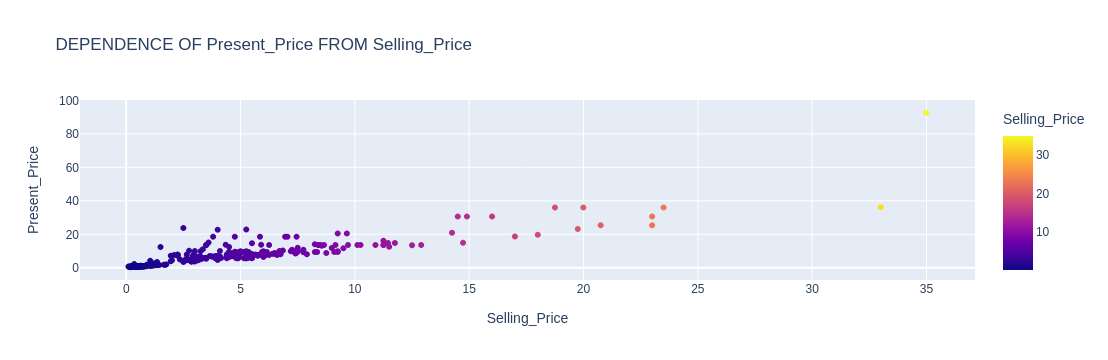

In [31]:
fig=px.scatter(df, x=numeric_cols[1], y=numeric_cols[2], color=target_col, title=f'DEPENDENCE OF {numeric_cols[2]} FROM {numeric_cols[1]}', labels={numeric_cols[1]: numeric_cols[1], numeric_cols[2]: numeric_cols[2]})
fig.write_html('interactive_scatter.html')
fig.show()

#Этот график подтверждает высокую корреляцию между этими двумя параметрами. Чем выше цена автомобиля при покупке, тем выше его нынешняя цена.

In [38]:
df.to_pickle('~/my_proj/data/clean_dataset.pkl')